# AIDI 1010 — Group Assignment 3
## Network Intrusion Detection: A Two-Stage AutoML Pipeline

**Group 9** — Joao Pedro Schneidr Perondi · Sehdev Singh · Ivan Rodriguez Cuevas

---

## Header Documentation

**Project.** We finish the Assignment 2 prototype by answering the two questions a SOC analyst asks in
order: *is this worth an alert?* (binary detector), then *what kind of attack is it?* (family classifier
running only on flagged traffic). A2 answered only the first.

**Strategy.** Same AutoML module (MLJAR), same dataset, same test split as A1/A2, so every number is
comparable. What changed:

| | Assignment 2 | Assignment 3 |
|---|---|---|
| Task | binary only | binary gate → attack-family classifier |
| Split | train / test | train / **validation** / test |
| Threshold | tuned on test | tuned on validation |
| Oversampling | SMOTENC before CV | SMOTENC **inside** each fold |
| Explainability | feature importance | SHAP global + per-alert |

**Audience.** A SOC analyst on a triage queue (alert, family label, per-alert explanation); secondarily a
team lead weighing a 60-minute AutoML ensemble against a model that trains in seconds.

**Challenges and resolutions.**

1. *Our A2 cross-validation score was inflated.* We oversampled before MLJAR's internal CV, so synthetic
   rows and their originals landed in different folds. That is why the leaderboard said 0.99 and the test
   set said 0.62. Fixed by putting SMOTENC inside an `imblearn` pipeline; quantified in Section 8.3.
2. *Our A2 threshold was selected on the test set*, making 0.65 optimistically biased. Fixed with a third
   split — threshold chosen on validation, test scored once.
3. *Nine attack classes, rarest has 10 rows.* We report the flat nine-class attempt as evidence of the
   ceiling, then group into four families that map to distinct SOC playbooks.
4. *MLJAR resets a DataFrame's index in place during `predict`*, silently desynchronising labels. Fixed by
   resetting all splits up front and passing copies.

### Generative AI Disclosure

Generative AI was only used for the verification of the written parts of this work, helping with the proper use of vocabulary and grammar.

## Problem Statement

**Context.** A SOC monitors network traffic for intrusions. Analyst time is the scarce resource: every
alert consumes it, every miss is a breach. Our data is 400 attack records against 9,600 benign — 96/4.

**Problem.** Signature-based detection generalises poorly to unseen patterns, while a naive classifier
scores 96% accuracy by predicting "benign" for everything. Both let intrusions through. An alert that says
only "something is wrong" also leaves the analyst to work out *what* before they can act.

**Scope.** Detection and triage on individual traffic records, using the available features (ports,
protocol, byte volumes, timestamps, user agent, internal flag). Not packet payload inspection or
session reconstruction.

**Cost asymmetry.** A false positive costs minutes; a false negative is an undetected intrusion. We
therefore tune the decision threshold rather than accepting 0.5, and report a recall-weighted operating
point alongside our F1 headline (Section 6.1).

**Binary vs. multi-class, resolved.** A1 mixed the two inconsistently; A2 committed to binary. Here they
are *sequential*: stage 1 is binary because the alert decision is binary; stage 2 is multi-class because it
sees only flagged traffic. This avoids a flat ten-class model dominated 96% by the benign class.

**Hypothesis.** A two-stage pipeline — imbalance-aware AutoML detector with a validation-tuned threshold,
then a family classifier on flagged traffic — will produce actionable, explainable alerts, and the limiting
factor will be the quantity of attack data rather than the model search.

**Data.** Public MIT-licensed Kaggle dataset (Talukdar, 2025), synthetic and structured for ML training.
Results demonstrate the pipeline; they would need re-validation on real captured traffic.

## 0. Setup

In [1]:
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import (classification_report, confusion_matrix, f1_score, fbeta_score,
                             precision_recall_curve)
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
from lightgbm import LGBMClassifier
from supervised.automl import AutoML

RANDOM_STATE     = 42
DATA_PATH        = "cybersecurity.csv"
TEST_SIZE        = 0.20        # unchanged from A2 -> identical test rows
VAL_SIZE_OF_TEMP = 0.25        # 60 / 20 / 20 overall
AUTOML_MODE      = "Compete"
TIME_LIMIT       = 3600
RESULTS_PATH_BIN = "AutoML_NIDS_compete"
CV_FOLDS         = 5
THRESHOLD_GRID   = np.arange(0.05, 0.95, 0.01)

BOT_AGENTS = ["sqlmap", "python", "curl", "zgrab"]

# Nine attack types grouped by the response playbook an analyst would open, not by class size.
FAMILY_MAP = {
    "brute-force": "credential-attack",   "credential-stuffing": "credential-attack",
    "sql-injection": "web-injection",     "xss": "web-injection",
    "command-injection": "web-injection", "port-scan": "reconnaissance",
    "ddos": "availability-postexploit",   "exploit-attempt": "availability-postexploit",
    "c2": "availability-postexploit",
}

sns.set_theme(style="whitegrid")
print("numpy", np.__version__, "| shap", shap.__version__, "| mode", AUTOML_MODE)

numpy 2.1.3 | shap 0.52.0 | mode Compete


## 1. Data and feature engineering

Reproduced from A1/A2 so the comparison holds. One change: `attack_type` is kept, since stage 2 needs it.

**Cleaning.** The dataset arrives without missing values, so cleaning is limited to dropping exact duplicate
records (`drop_duplicates`), lower-casing `user_agent` before substring matching, and removing the three pure
identifiers (`url`, `src_ip`, `dst_ip`) — high-cardinality columns that would let the model memorise hosts
rather than learn behaviour. Byte volumes are log-transformed rather than trimmed, since the heavy right tail
is signal (DDoS) rather than error.

In [2]:
df = pd.read_csv(DATA_PATH)

df["timestamp"]   = pd.to_datetime(df["timestamp"])
df["hour"]        = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["month"]       = df["timestamp"].dt.month
df["is_weekend"]  = df["timestamp"].dt.dayofweek.isin([5, 6]).astype(int)
df.drop(columns=["timestamp"], inplace=True)

df["log_bytes_sent"]     = np.log1p(df["bytes_sent"])
df["log_bytes_received"] = np.log1p(df["bytes_received"])

# IANA range carries more signal than the raw port number.
bins, labels = [-1, 1023, 49151, 65535], ["System", "Registered", "Dynamic"]
df["dst_port_category"] = pd.cut(df["dst_port"], bins=bins, labels=labels).astype(str)
df["src_port_category"] = pd.cut(df["src_port"], bins=bins, labels=labels).astype(str)

df["user_agent"] = df["user_agent"].astype(str).str.lower()
df["riskAgent"]  = df["user_agent"].apply(lambda ua: int(any(p in ua for p in BOT_AGENTS)))

df.drop(columns=["url", "src_ip", "dst_ip"], inplace=True)
df["is_internal_traffic"] = df["is_internal_traffic"].astype(int)

df["label"]         = (df["attack_type"] != "benign").astype(int)
df["attack_family"] = df["attack_type"].map(FAMILY_MAP).fillna("benign")
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print("Shape:", df.shape)
print(df["attack_type"].value_counts())

Shape: (10000, 19)
attack_type
benign                 9600
brute-force             108
port-scan                81
sql-injection            64
xss                      34
credential-stuffing      28
ddos                     27
command-injection        26
exploit-attempt          22
c2                       10
Name: count, dtype: int64


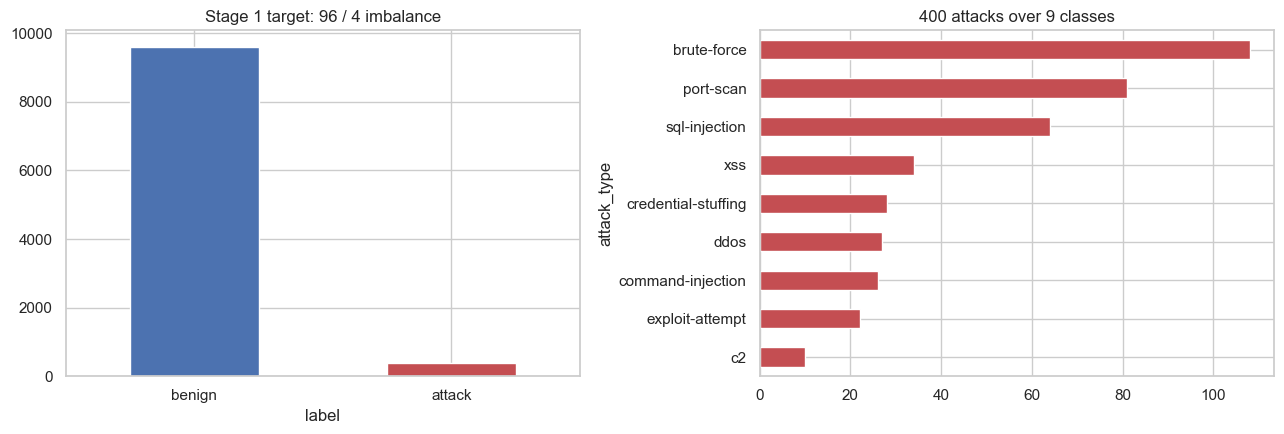

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

df["label"].map({0: "benign", 1: "attack"}).value_counts().plot(
    kind="bar", ax=axes[0], color=["#4C72B0", "#C44E52"], rot=0)
axes[0].set_title("Stage 1 target: 96 / 4 imbalance")

atk = df[df["label"] == 1]["attack_type"].value_counts()
atk.plot(kind="barh", ax=axes[1], color="#C44E52")
axes[1].invert_yaxis()
axes[1].set_title(f"{atk.sum()} attacks over {len(atk)} classes")

plt.tight_layout(); plt.show()

## 2. Three-way split

A2 tuned its threshold on the test set, so its 0.65 was optimistically biased. The first split here is
identical to A2 (`test_size=0.20`, `random_state=42`, stratified), so the test set is the same 2,000 rows;
validation is carved from the remaining 80%. The cost is a smaller training set (240 attacks vs. 320), so a
small drop in test F1 is expected — that is the bias being removed, not the model getting worse.

In [4]:
X, y, at, af = (df.drop(columns=["label", "attack_type", "attack_family"]),
                df["label"], df["attack_type"], df["attack_family"])

X_temp, X_test, y_temp, y_test, at_temp, at_test, af_temp, af_test = train_test_split(
    X, y, at, af, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

X_train, X_val, y_train, y_val, at_train, at_val, af_train, af_val = train_test_split(
    X_temp, y_temp, at_temp, af_temp,
    test_size=VAL_SIZE_OF_TEMP, random_state=RANDOM_STATE, stratify=y_temp)

# MLJAR resets a DataFrame's index in place during predict; align everything now so later
# boolean masks such as X_train[y_train == 1] cannot silently misalign.
for part in (X_train, X_val, X_test, y_train, y_val, y_test,
             at_train, at_val, at_test, af_train, af_val, af_test):
    part.reset_index(drop=True, inplace=True)

CAT_COLS = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
CAT_IDX  = [X_train.columns.get_loc(c) for c in CAT_COLS]

print(pd.DataFrame({
    "rows":    [len(X_train), len(X_val), len(X_test)],
    "attacks": [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
    "purpose": ["fit models", "select threshold", "reported once"],
}, index=["train", "validation", "test"]))
print("\nCategorical:", CAT_COLS)

            rows  attacks           purpose
train       6000      240        fit models
validation  2000       80  select threshold
test        2000       80     reported once

Categorical: ['protocol', 'user_agent', 'dst_port_category', 'src_port_category']


## 3. Balance the training data

`SMOTENC`, not `SMOTE`: four features are categorical, and plain SMOTE would interpolate them numerically
into meaningless values. Only the training split is resampled — validation and test stay at 96/4 so the
threshold and the metrics reflect production conditions.

In [5]:
X_train_bal, y_train_bal = SMOTENC(
    categorical_features=CAT_IDX, random_state=RANDOM_STATE).fit_resample(X_train, y_train)

print("before:", y_train.value_counts().to_dict())
print("after: ", pd.Series(y_train_bal).value_counts().to_dict())

before: {0: 5760, 1: 240}
after:  {0: 5760, 1: 5760}


## 4. Stage 1 — AutoML binary detector

`Compete` mode runs golden features, feature selection, hill climbing, stacking and ensembling. Our run
trained 58 models in 59.8 minutes. The cell loads the saved run if one exists rather than retraining.

In [6]:
if os.path.exists(os.path.join(RESULTS_PATH_BIN, "params.json")):
    automl = AutoML(results_path=RESULTS_PATH_BIN)
    print("Loaded saved run — no retraining.")
else:
    automl = AutoML(
        mode=AUTOML_MODE, ml_task="binary_classification", eval_metric="f1",
        algorithms=["Linear", "Random Forest", "Xgboost", "CatBoost",
                    "LightGBM", "Extra Trees", "Neural Network"],
        total_time_limit=TIME_LIMIT, random_state=RANDOM_STATE,
        results_path=RESULTS_PATH_BIN)
    automl.fit(X_train_bal, y_train_bal)

Loaded saved run — no retraining.


### 4.1 What won, and what it cost

We read `leaderboard.csv` directly instead of calling `automl.report()`, whose interactive HTML inflated
our A2 notebook to 42 MB in one output cell and does not render for a reader opening the `.ipynb`.

58 models, 59.8 minutes total



,name,model_type,metric_value,train_time
0,Ensemble_Stacked,Ensemble,0.990415,10.48
1,5_Default_RandomForest_Stacked,Random Forest,0.990328,57.19
2,43_ExtraTrees_Stacked,Extra Trees,0.990244,43.22
3,34_RandomForest_Stacked,Random Forest,0.990068,59.63
4,7_Xgboost_categorical_mix_Stacked,Xgboost,0.989983,29.92
5,25_CatBoost_Stacked,CatBoost,0.989635,133.63
6,7_Xgboost_Stacked,Xgboost,0.989635,24.94
7,62_LightGBM,LightGBM,0.989446,41.55
8,64_LightGBM,LightGBM,0.989446,43.95
9,Ensemble,Ensemble,0.989446,9.01


,best_f1,models,minutes
model_type,,,
Ensemble,0.990415,2,0.3
Random Forest,0.990328,6,3.7
Extra Trees,0.990244,5,2.0
Xgboost,0.989983,8,4.3
CatBoost,0.989635,8,30.5
LightGBM,0.989446,24,15.7
Neural Network,0.987618,5,3.2


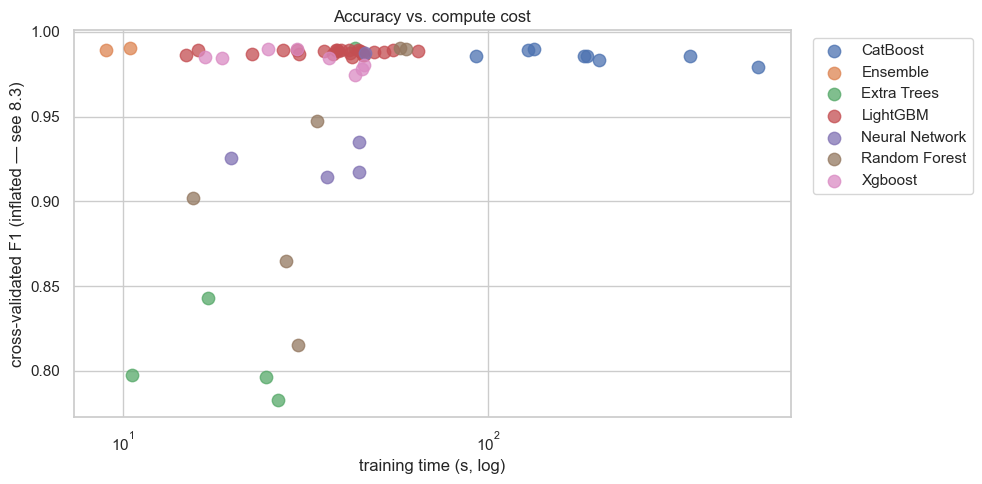

In [7]:
leaderboard = (pd.read_csv(os.path.join(RESULTS_PATH_BIN, "leaderboard.csv"))
                 .sort_values("metric_value", ascending=False).reset_index(drop=True))

print(f"{len(leaderboard)} models, {leaderboard['train_time'].sum()/60:.1f} minutes total\n")
display(leaderboard.head(10)[["name", "model_type", "metric_value", "train_time"]])
display(leaderboard.groupby("model_type").agg(best_f1=("metric_value", "max"),
                                              models=("name", "count"),
                                              minutes=("train_time", lambda s: round(s.sum()/60, 1)))
                   .sort_values("best_f1", ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
for mtype, grp in leaderboard.groupby("model_type"):
    ax.scatter(grp["train_time"], grp["metric_value"], label=mtype, s=80, alpha=0.75)
ax.set_xscale("log")
ax.set_xlabel("training time (s, log)")
ax.set_ylabel("cross-validated F1 (see 8.3 — same leakage mechanism)")
ax.set_title("Accuracy vs. compute cost")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

## 5. Threshold selection on validation

The default 0.5 assumes balanced classes and symmetric error costs; neither holds. We pick the threshold
that maximises attack F1 on validation, then apply it to test once.

Selected: 0.20 (validation F1 0.696)
Default 0.50 would give validation F1 0.613


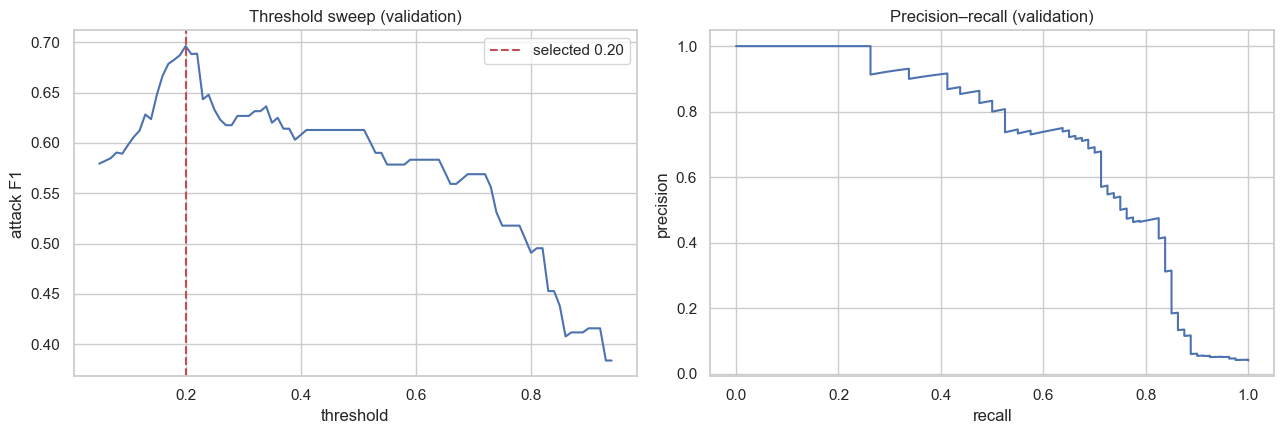

In [8]:
proba_val = automl.predict_proba(X_val.copy())[:, 1]   # .copy(): MLJAR mutates the index

f1_by_threshold = np.array([f1_score(y_val, (proba_val >= t).astype(int)) for t in THRESHOLD_GRID])
BEST_THRESHOLD  = float(THRESHOLD_GRID[f1_by_threshold.argmax()])

print(f"Selected: {BEST_THRESHOLD:.2f} (validation F1 {f1_by_threshold.max():.3f})")
print(f"Default 0.50 would give validation F1 {f1_score(y_val, (proba_val >= 0.5).astype(int)):.3f}")

prec, rec, pr_thr = precision_recall_curve(y_val, proba_val)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(THRESHOLD_GRID, f1_by_threshold)
axes[0].axvline(BEST_THRESHOLD, ls="--", color="#C44E52", label=f"selected {BEST_THRESHOLD:.2f}")
axes[0].set_xlabel("threshold"); axes[0].set_ylabel("attack F1"); axes[0].legend()
axes[0].set_title("Threshold sweep (validation)")
axes[1].plot(rec, prec)
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
axes[1].set_title("Precision–recall (validation)")
plt.tight_layout(); plt.show()

## 6. Test evaluation — measured once

              precision    recall  f1-score   support

      benign      0.985     0.983     0.984      1920
      attack      0.614     0.637     0.626        80

    accuracy                          0.970      2000
   macro avg      0.800     0.810     0.805      2000
weighted avg      0.970     0.970     0.970      2000



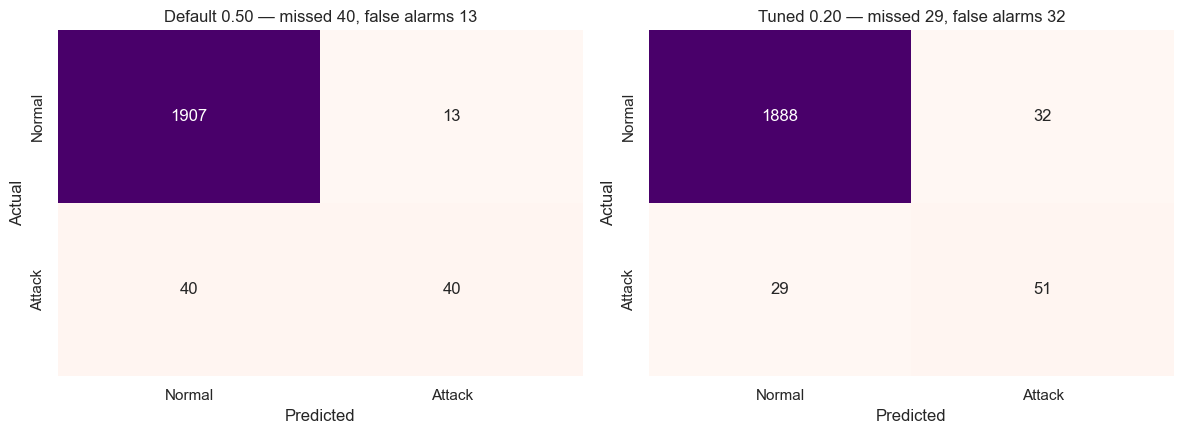

In [9]:
proba_test  = automl.predict_proba(X_test.copy())[:, 1]
y_pred_test = (proba_test >= BEST_THRESHOLD).astype(int)

rep = classification_report(y_test, y_pred_test, digits=3, output_dict=True, zero_division=0)["1"]
A3_F1, A3_RECALL, A3_PREC = rep["f1-score"], rep["recall"], rep["precision"]

print(classification_report(y_test, y_pred_test, digits=3,
                            target_names=["benign", "attack"], zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, preds, title in [(axes[0], (proba_test >= 0.5).astype(int), "Default 0.50"),
                         (axes[1], y_pred_test, f"Tuned {BEST_THRESHOLD:.2f}")]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="RdPu", cbar=False, ax=ax,
                xticklabels=["Normal", "Attack"], yticklabels=["Normal", "Attack"])
    ax.set_title(f"{title} — missed {cm[1,0]}, false alarms {cm[0,1]}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()

### 6.1 Is F1 the right objective?

Our problem statement says false negatives cost more, but F1 weights precision and recall equally — so
optimising it contradicts our own cost model. F2 weights recall four times as heavily. We keep the F1
threshold as the headline for comparability with A1/A2 and report F2 as the operating point we would
actually deploy.

Note that the F2 threshold scores *higher on test F1* than the threshold we selected by maximising
validation F1. This is not an error: both thresholds were chosen on validation and the F1 surface is
almost flat between 0.18 and 0.20, so which one wins on unseen data is noise. It is what an honest
held-out evaluation looks like — had we tuned on test, as in Assignment 2, this could not have happened.

On our data the choice is not even a trade-off: moving to the F2 point catches five more attacks for six
more false alarms and scores better on both metrics. Recall rises from 0.637 to 0.700 while false alarms
go from 32 to 38 out of 1,920 benign records. We would deploy the F2 point.

,threshold,recall,precision,F1,F2,missed,false alarms
operating point,,,,,,,
default,0.50,0.500,0.755,0.602,0.536,40,13
F1-optimal (reported),0.20,0.637,0.614,0.626,0.633,29,32
F2-optimal,0.18,0.700,0.596,0.644,0.676,24,38


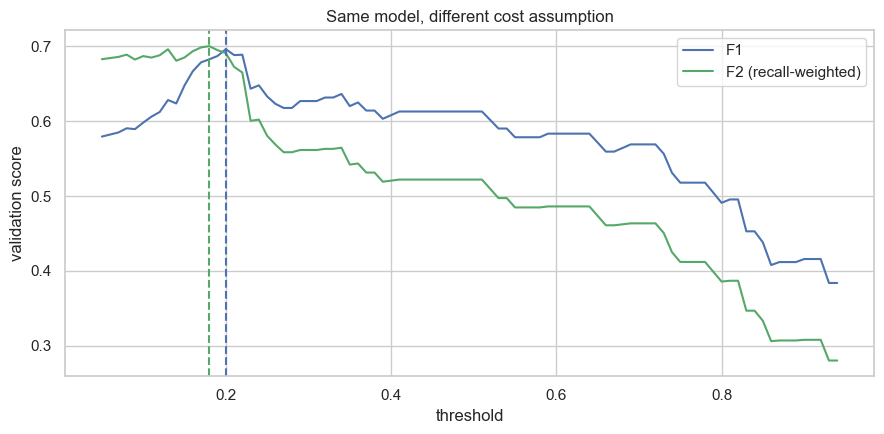

In [10]:
f2_by_threshold = np.array([fbeta_score(y_val, (proba_val >= t).astype(int), beta=2)
                            for t in THRESHOLD_GRID])
THRESHOLD_F2 = float(THRESHOLD_GRID[f2_by_threshold.argmax()])

def operating_point(t, name):
    pred = (proba_test >= t).astype(int)
    cm   = confusion_matrix(y_test, pred)
    r    = classification_report(y_test, pred, output_dict=True, zero_division=0)["1"]
    return {"operating point": name, "threshold": round(t, 2),
            "recall": round(r["recall"], 3), "precision": round(r["precision"], 3),
            "F1": round(r["f1-score"], 3), "F2": round(fbeta_score(y_test, pred, beta=2), 3),
            "missed": int(cm[1, 0]), "false alarms": int(cm[0, 1])}

display(pd.DataFrame([operating_point(0.50, "default"),
                      operating_point(BEST_THRESHOLD, "F1-optimal (reported)"),
                      operating_point(THRESHOLD_F2, "F2-optimal")]).set_index("operating point"))

plt.figure(figsize=(9, 4.5))
plt.plot(THRESHOLD_GRID, f1_by_threshold, label="F1", color="#4C72B0")
plt.plot(THRESHOLD_GRID, f2_by_threshold, label="F2 (recall-weighted)", color="#55A868")
plt.axvline(BEST_THRESHOLD, ls="--", color="#4C72B0"); plt.axvline(THRESHOLD_F2, ls="--", color="#55A868")
plt.xlabel("threshold"); plt.ylabel("validation score")
plt.title("Same model, different cost assumption"); plt.legend()
plt.tight_layout(); plt.show()

## 7. Explainability — SHAP

`TreeExplainer` cannot traverse MLJAR's stacked ensemble, and `KernelExplainer` is slow. We fit a
surrogate LightGBM on the same balanced data and explain that, reporting the agreement so the reader can
judge how far the explanation transfers.

Surrogate F1 0.638 vs AutoML F1 0.626
Prediction agreement: 98.0%


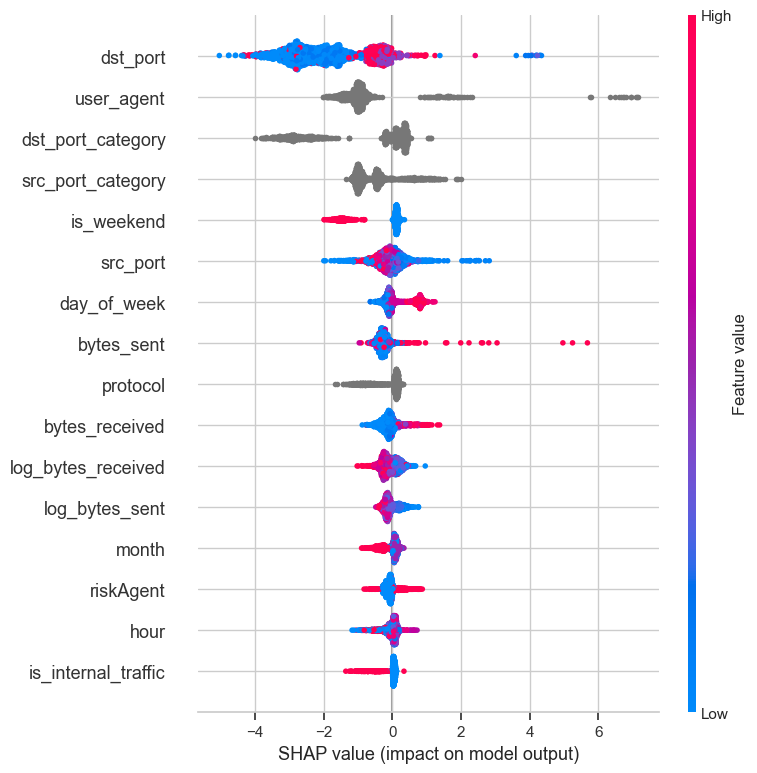

,feature,mean |SHAP|
0,dst_port,1.863589
1,user_agent,1.113403
2,dst_port_category,1.030246
3,src_port_category,0.763404
4,is_weekend,0.494172
5,src_port,0.315098
6,day_of_week,0.301403
7,bytes_sent,0.298645
8,protocol,0.251485
9,bytes_received,0.205045


In [11]:
encoder = OrdinalEncoder(handle_unknown="use_encoded_value",
                         unknown_value=-1).fit(X_train_bal[CAT_COLS])

def encode(frame):
    out = frame.copy()
    out[CAT_COLS] = encoder.transform(out[CAT_COLS])
    for col in CAT_COLS:
        out[col] = out[col].astype("category")
    return out

surrogate = LGBMClassifier(random_state=RANDOM_STATE, verbose=-1).fit(encode(X_train_bal), y_train_bal)
X_test_enc     = encode(X_test)
surrogate_pred = (surrogate.predict_proba(X_test_enc)[:, 1] >= BEST_THRESHOLD).astype(int)

print(f"Surrogate F1 {f1_score(y_test, surrogate_pred):.3f} vs AutoML F1 {A3_F1:.3f}")
print(f"Prediction agreement: {(surrogate_pred == y_pred_test).mean():.1%}")

shap_values = shap.TreeExplainer(surrogate)(X_test_enc)
shap.summary_plot(shap_values, X_test_enc, show=False)
plt.tight_layout(); plt.show()

display(pd.DataFrame({"feature": X_test_enc.columns,
                      "mean |SHAP|": np.abs(shap_values.values).mean(axis=0)})
          .sort_values("mean |SHAP|", ascending=False).head(10).reset_index(drop=True))

### 7.1 Per-alert explanations, and what the ranking showed

The waterfall plots are what an analyst would see next to an alert. Two findings we did not expect:

- **`user_agent` is not the top driver.** `dst_port` is, and port-derived features take three of the top
  four positions.
- **`riskAgent` does not reach the top ten.** Given the raw `user_agent` string, the model extracts more
  than our hand-built bot flag encoded — we engineered a feature the model did not need.

Port dominance may also be partly a dataset artefact: synthetic generators often assign attack types to
characteristic ports, and real traffic is far noisier. This is the main limitation in Section 13.


=== true positive — row 64, score 0.233 ===


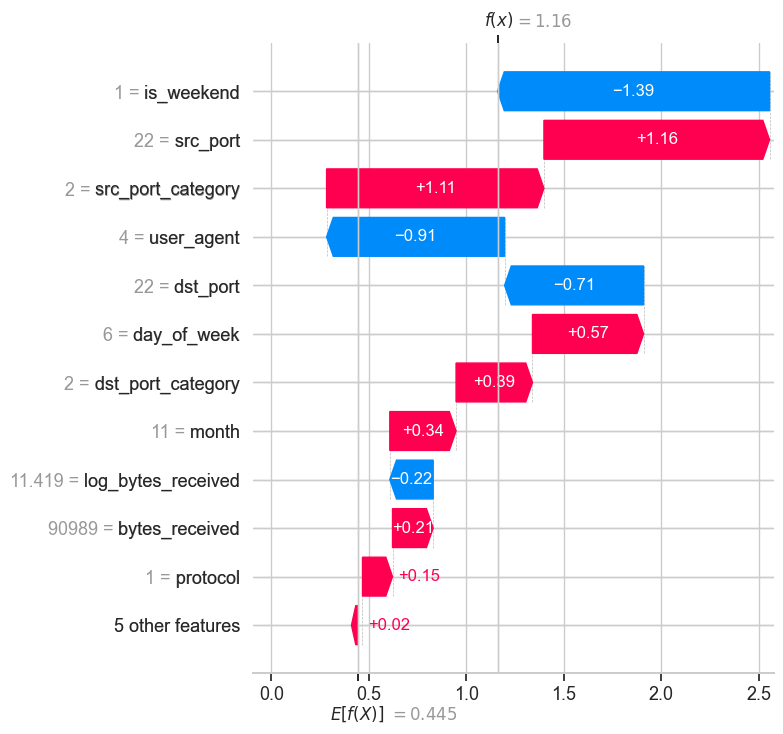


=== false positive — row 71, score 0.835 ===


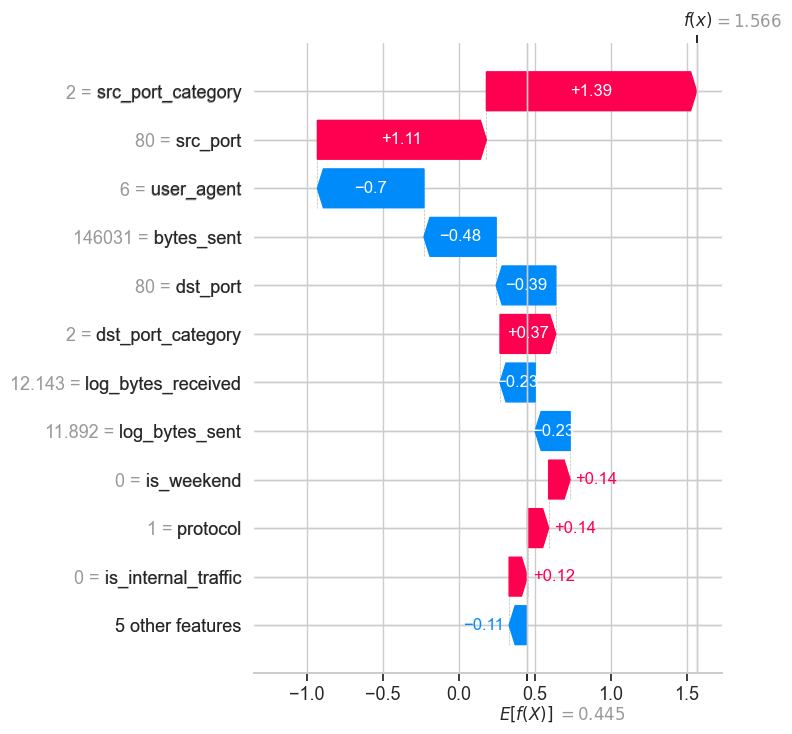


=== false negative — row 1, score 0.011 ===


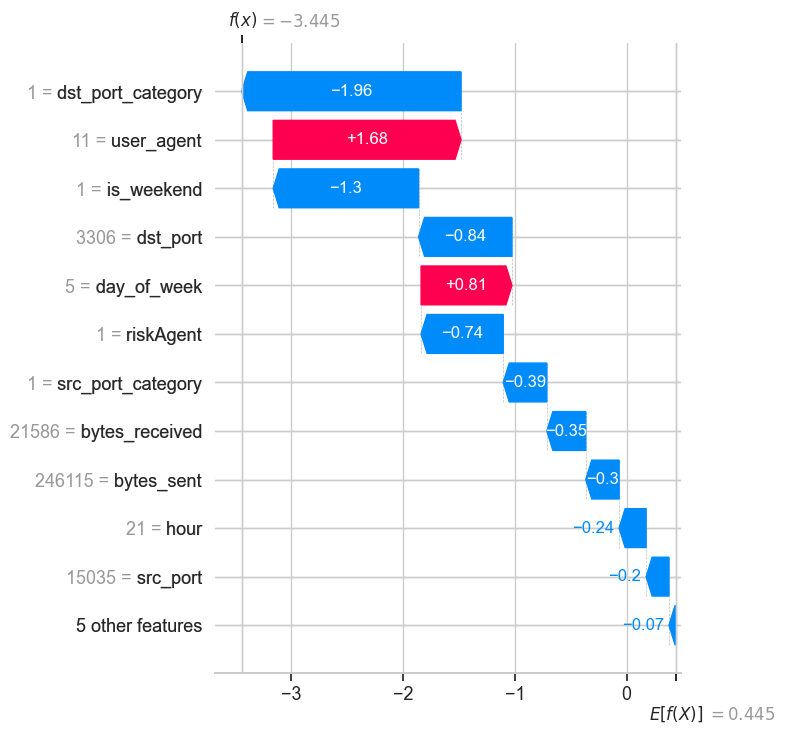

In [12]:
for label, pool in [("true positive",  np.where((y_test.values == 1) & (y_pred_test == 1))[0]),
                    ("false positive", np.where((y_test.values == 0) & (y_pred_test == 1))[0]),
                    ("false negative", np.where((y_test.values == 1) & (y_pred_test == 0))[0])]:
    if len(pool) == 0:
        print(f"{label}: none"); continue
    i = int(pool[0])
    print(f"\n=== {label} — row {i}, score {proba_test[i]:.3f} ===")
    shap.plots.waterfall(shap_values[i], max_display=12, show=False)
    plt.tight_layout(); plt.show()

## 8. Stage 2 — what kind of attack?

Stage 2 sees only flagged traffic, so it trains only on attack rows. The pool is train + validation
attacks: validation was used only to pick a scalar threshold, never to fit stage 1, so reusing those 80
rows costs no independence and gives a 33% larger pool.

In [13]:
X_pool  = pd.concat([X_train[y_train == 1], X_val[y_val == 1]]).reset_index(drop=True)
at_pool = pd.concat([at_train[y_train == 1], at_val[y_val == 1]]).reset_index(drop=True)
af_pool = pd.concat([af_train[y_train == 1], af_val[y_val == 1]]).reset_index(drop=True)
POOL_CAT_IDX = [X_pool.columns.get_loc(c) for c in CAT_COLS]

print(f"{len(X_pool)} attack records\n")
print(at_pool.value_counts(), "\n")
print(af_pool.value_counts())

320 attack records

attack_type
brute-force            86
port-scan              69
sql-injection          45
xss                    27
credential-stuffing    25
ddos                   24
command-injection      19
exploit-attempt        18
c2                      7
Name: count, dtype: int64 

attack_family
credential-attack           111
web-injection                91
reconnaissance               69
availability-postexploit     49
Name: count, dtype: int64


### 8.1 Cross-validation done correctly

SMOTENC sits inside an `imblearn` pipeline so it refits on each training fold only. `k_neighbors` must be
below the rarest class's fold-level count, so we compute it rather than hard-coding 5.

In [14]:
def safe_k_neighbours(labels, cap=5, folds=CV_FOLDS):
    smallest_in_fold = int(np.floor(pd.Series(labels).value_counts().min() * (folds - 1) / folds))
    return max(1, min(cap, smallest_in_fold - 1))

def multiclass_pipeline(k):
    return ImbPipeline([
        ("smote",  SMOTENC(categorical_features=POOL_CAT_IDX, k_neighbors=k,
                           random_state=RANDOM_STATE)),
        ("encode", ColumnTransformer([("cat", OrdinalEncoder(handle_unknown="use_encoded_value",
                                                             unknown_value=-1), CAT_COLS)],
                                     remainder="passthrough")),
        ("model",  LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)),
    ])

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

### 8.2 Attempt A — flat nine-class

k_neighbors = 4 (rarest class 7 rows)

                     precision    recall  f1-score   support

        brute-force      0.657     0.756     0.703        86
                 c2      0.000     0.000     0.000         7
  command-injection      0.200     0.263     0.227        19
credential-stuffing      0.107     0.120     0.113        25
               ddos      0.833     0.833     0.833        24
    exploit-attempt      0.333     0.333     0.333        18
          port-scan      0.891     0.710     0.790        69
      sql-injection      0.463     0.422     0.442        45
                xss      0.115     0.111     0.113        27

           accuracy                          0.531       320
          macro avg      0.400     0.394     0.395       320
       weighted avg      0.545     0.531     0.535       320



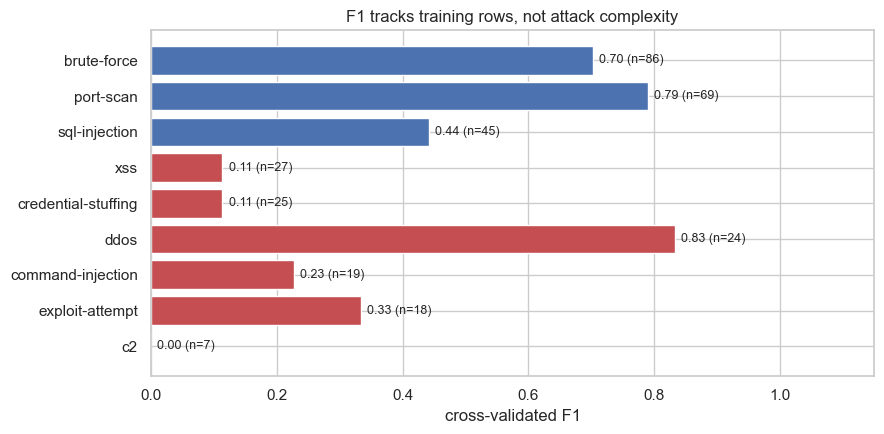

In [15]:
k_flat      = safe_k_neighbours(at_pool)
pred_flat   = cross_val_predict(multiclass_pipeline(k_flat), X_pool, at_pool, cv=cv)
report_flat = classification_report(at_pool, pred_flat, digits=3, zero_division=0, output_dict=True)
FLAT_MACRO_F1 = report_flat["macro avg"]["f1-score"]

print(f"k_neighbors = {k_flat} (rarest class {at_pool.value_counts().min()} rows)\n")
print(classification_report(at_pool, pred_flat, digits=3, zero_division=0))

flat_f1 = (pd.Series({c: report_flat[c]["f1-score"] for c in at_pool.unique()})
             .to_frame("f1").join(at_pool.value_counts().rename("rows")).sort_values("rows"))
plt.figure(figsize=(9, 4.5))
plt.barh(flat_f1.index, flat_f1["f1"],
         color=["#C44E52" if r < 30 else "#4C72B0" for r in flat_f1["rows"]])
for i, (v, n) in enumerate(zip(flat_f1["f1"], flat_f1["rows"])):
    plt.text(v + 0.01, i, f"{v:.2f} (n={n})", va="center", fontsize=9)
plt.xlim(0, 1.15); plt.xlabel("cross-validated F1")
plt.title("F1 tracks training rows, not attack complexity")
plt.tight_layout(); plt.show()

### 8.3 How much did the leakage inflate our prototype?

Running the same problem the wrong way — oversample everything, then cross-validate — measures the effect
directly, and explains the gap between our A2 leaderboard F1 and our A2 test F1.

Macro F1 — SMOTE before CV (wrong): 0.831
Macro F1 — SMOTE inside CV (right): 0.395



,rows,before CV,inside CV,inflation
c2,7,0.933,0.000,0.933
exploit-attempt,18,0.912,0.333,0.579
command-injection,19,0.784,0.227,0.556
ddos,24,0.971,0.833,0.137
credential-stuffing,25,0.777,0.113,0.664
xss,27,0.771,0.113,0.658
sql-injection,45,0.760,0.442,0.318
port-scan,69,0.816,0.790,0.025
brute-force,86,0.753,0.703,0.050


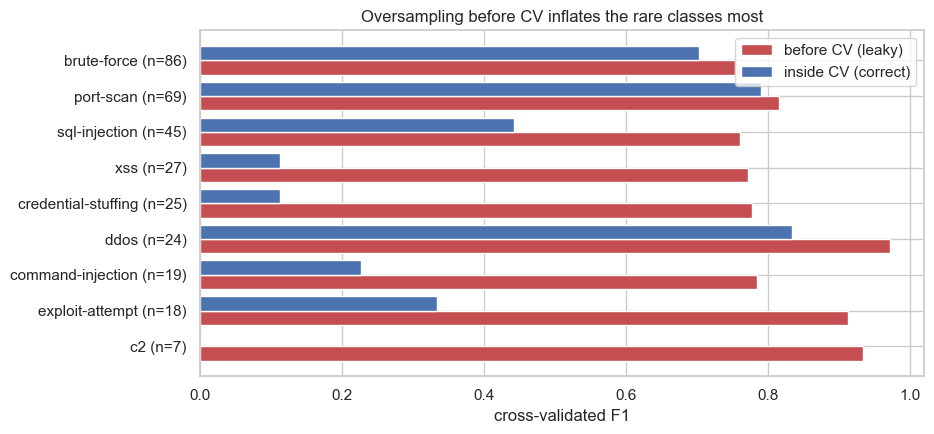

In [16]:
X_leaky, y_leaky = SMOTENC(categorical_features=POOL_CAT_IDX, k_neighbors=k_flat,
                           random_state=RANDOM_STATE).fit_resample(X_pool, at_pool)
leaky_pipeline = ImbPipeline([
    ("encode", ColumnTransformer([("cat", OrdinalEncoder(handle_unknown="use_encoded_value",
                                                         unknown_value=-1), CAT_COLS)],
                                 remainder="passthrough")),
    ("model",  LGBMClassifier(random_state=RANDOM_STATE, verbose=-1))])
report_leaky = classification_report(y_leaky, cross_val_predict(leaky_pipeline, X_leaky, y_leaky, cv=cv),
                                     digits=3, zero_division=0, output_dict=True)

leakage = pd.DataFrame({
    "rows":       at_pool.value_counts(),
    "before CV":  {c: report_leaky[c]["f1-score"] for c in at_pool.unique()},
    "inside CV":  {c: report_flat[c]["f1-score"]  for c in at_pool.unique()},
}).sort_values("rows")
leakage["inflation"] = (leakage["before CV"] - leakage["inside CV"]).round(3)

print(f"Macro F1 — SMOTE before CV (wrong): {report_leaky['macro avg']['f1-score']:.3f}")
print(f"Macro F1 — SMOTE inside CV (right): {FLAT_MACRO_F1:.3f}\n")
display(leakage.round(3))

pos = np.arange(len(leakage))
plt.figure(figsize=(9.5, 4.5))
plt.barh(pos - 0.2, leakage["before CV"], height=0.4, color="#C44E52", label="before CV (leaky)")
plt.barh(pos + 0.2, leakage["inside CV"], height=0.4, color="#4C72B0", label="inside CV (correct)")
plt.yticks(pos, [f"{c} (n={n})" for c, n in zip(leakage.index, leakage["rows"])])
plt.xlabel("cross-validated F1"); plt.legend()
plt.title("Oversampling before CV inflates the rare classes most")
plt.tight_layout(); plt.show()

### 8.4 Attempt B — four response families

The nine-class result is evidence of a data ceiling, not a usable classifier. Grouping keeps the
operationally meaningful distinction and gives every class enough rows.

                          precision    recall  f1-score   support

availability-postexploit      0.851     0.816     0.833        49
       credential-attack      0.940     0.982     0.960       111
          reconnaissance      0.924     0.884     0.904        69
           web-injection      0.967     0.967     0.967        91

                accuracy                          0.931       320
               macro avg      0.920     0.912     0.916       320
            weighted avg      0.931     0.931     0.931       320

Flat 9-class macro F1: 0.395  |  4-family macro F1: 0.916


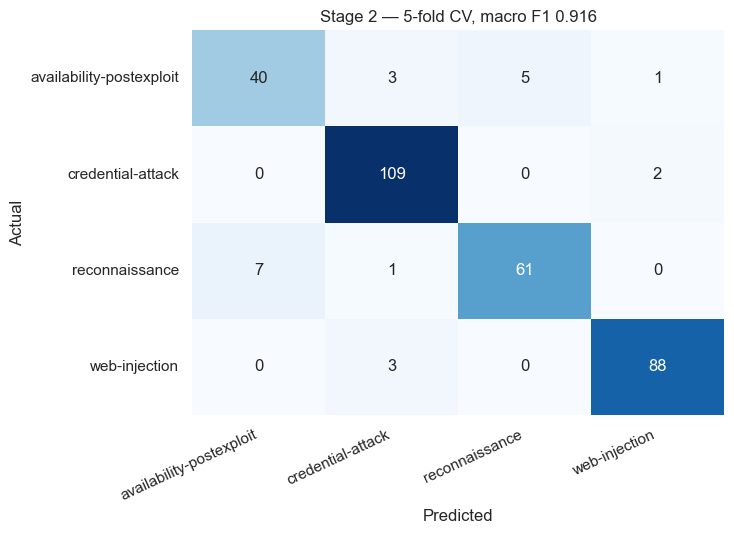

In [17]:
k_family       = safe_k_neighbours(af_pool)
pred_family_cv = cross_val_predict(multiclass_pipeline(k_family), X_pool, af_pool, cv=cv)
FAMILY_MACRO_F1 = classification_report(af_pool, pred_family_cv, output_dict=True,
                                        zero_division=0)["macro avg"]["f1-score"]

print(classification_report(af_pool, pred_family_cv, digits=3, zero_division=0))
print(f"Flat 9-class macro F1: {FLAT_MACRO_F1:.3f}  |  4-family macro F1: {FAMILY_MACRO_F1:.3f}")

fam_labels = sorted(af_pool.unique())
plt.figure(figsize=(7.5, 5.5))
sns.heatmap(confusion_matrix(af_pool, pred_family_cv, labels=fam_labels),
            annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=fam_labels, yticklabels=fam_labels)
plt.title(f"Stage 2 — {CV_FOLDS}-fold CV, macro F1 {FAMILY_MACRO_F1:.3f}")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks(rotation=25, ha="right"); plt.tight_layout(); plt.show()

## 9. The pipeline end to end

Stage 1 decides whether to alert; stage 2 labels what it raised. This shows both failure modes an analyst experiences: an attack that never alerted, and an alert with the wrong playbook.

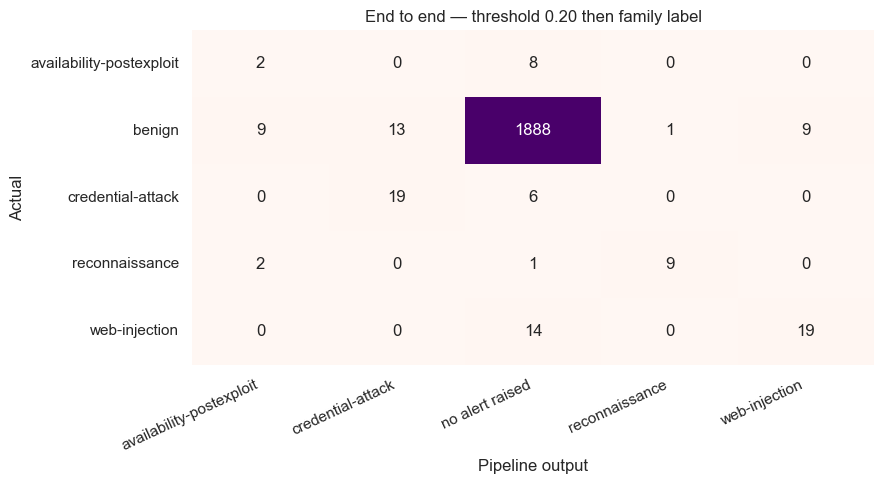

Attacks: 80 | alerted: 51 | correct family: 49 | missed: 29
False alarms: 32 of 1920


In [18]:
stage2 = multiclass_pipeline(min(5, int(af_pool.value_counts().min()) - 1)).fit(X_pool, af_pool)

alerts        = y_pred_test.astype(bool)
pred_pipeline = np.full(len(X_test), "no alert raised", dtype=object)
if alerts.sum():
    pred_pipeline[alerts] = stage2.predict(X_test[alerts])

plt.figure(figsize=(9, 5))
sns.heatmap(pd.crosstab(pd.Series(af_test.values, name="Actual"),
                        pd.Series(pred_pipeline, name="Pipeline output")),
            annot=True, fmt="d", cmap="RdPu", cbar=False)
plt.title(f"End to end — threshold {BEST_THRESHOLD:.2f} then family label")
plt.xticks(rotation=25, ha="right"); plt.tight_layout(); plt.show()

is_attack = af_test.values != "benign"
missed    = (pred_pipeline[is_attack] == "no alert raised").sum()
print(f"Attacks: {is_attack.sum()} | alerted: {is_attack.sum() - missed} | "
      f"correct family: {(pred_pipeline[is_attack] == af_test.values[is_attack]).sum()} | "
      f"missed: {missed}")
print(f"False alarms: {(pred_pipeline[~is_attack] != 'no alert raised').sum()} of {(~is_attack).sum()}")

## 10. Results across the three assignments

Same 2,000 test rows throughout. Two caveats: A2's 0.65 was test-tuned and so optimistically biased, and
A3 trains on 240 attack rows rather than 320.

,Configuration,Attack F1,Recall,Precision
0,A1 Logistic Regression,0.230,0.690,0.140
1,A1 Random Forest,0.390,0.350,0.430
2,A1 XGBoost (tuned + threshold),0.630,0.600,0.670
3,"A2 MLJAR Perform, no user_agent",0.410,0.290,0.720
4,A2 MLJAR Perform + SMOTENC,0.480,0.410,0.570
5,A2 MLJAR Compete (default 0.5),0.620,0.560,0.690
6,A2 MLJAR Compete (test-tuned),0.650,0.630,0.680
7,A3 Two-stage (validation-tuned 0.20),0.626,0.637,0.614


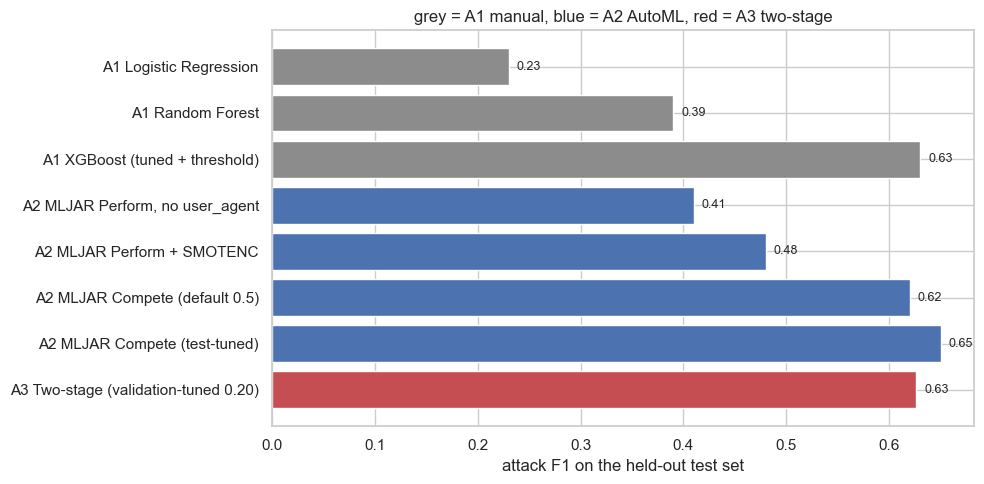

,A2,A3
capability,,
Alert / no alert,"yes (0.65, test-tuned)","yes (0.63, validation-tuned)"
Attack family label,no,yes (macro F1 0.92)
Flat 9-class,no,attempted (macro F1 0.40 — data-limited)
Per-alert explanation,no,yes (SHAP)


In [19]:
results = pd.DataFrame([
    ("A1 Logistic Regression",                   0.23, 0.69, 0.14),
    ("A1 Random Forest",                         0.39, 0.35, 0.43),
    ("A1 XGBoost (tuned + threshold)",           0.63, 0.60, 0.67),
    ("A2 MLJAR Perform, no user_agent",          0.41, 0.29, 0.72),
    ("A2 MLJAR Perform + SMOTENC",               0.48, 0.41, 0.57),
    ("A2 MLJAR Compete (default 0.5)",           0.62, 0.56, 0.69),
    ("A2 MLJAR Compete (test-tuned)",            0.65, 0.63, 0.68),
    (f"A3 Two-stage (validation-tuned {BEST_THRESHOLD:.2f})",
     round(A3_F1, 3), round(A3_RECALL, 3), round(A3_PREC, 3)),
], columns=["Configuration", "Attack F1", "Recall", "Precision"])
display(results)

plt.figure(figsize=(10, 5))
plt.barh(results["Configuration"], results["Attack F1"],
         color=["#8C8C8C"]*3 + ["#4C72B0"]*4 + ["#C44E52"])
for i, v in enumerate(results["Attack F1"]):
    plt.text(v + 0.008, i, f"{v:.2f}", va="center", fontsize=9)
plt.gca().invert_yaxis(); plt.xlabel("attack F1 on the held-out test set")
plt.title("grey = A1 manual, blue = A2 AutoML, red = A3 two-stage")
plt.tight_layout(); plt.show()

display(pd.DataFrame({
    "capability": ["Alert / no alert", "Attack family label", "Flat 9-class", "Per-alert explanation"],
    "A2": ["yes (0.65, test-tuned)", "no", "no", "no"],
    "A3": [f"yes ({A3_F1:.2f}, validation-tuned)", f"yes (macro F1 {FAMILY_MACRO_F1:.2f})",
           f"attempted (macro F1 {FLAT_MACRO_F1:.2f} — data-limited)", "yes (SHAP)"],
}).set_index("capability"))

### 10.1 Against the research papers, and did our hypothesis hold?

Our three papers predicted specific things. Two of the three predictions held for us; one did not, and the
gap is informative.

| | Paper's setup | Paper's result | Ours | Verdict |
|---|---|---|---|---|
| **Gyimah et al. (2024)** — AutoML NIDS | MLJAR stacked ensemble, NSL-KDD | 89% F1; beat RF (78%) and XGBoost (80%) | AutoML 0.626 vs. hand-tuned XGBoost 0.63 | **Partly held** |
| **Liu et al. (2025)** — AutoML survey | 15+ methods, CICIDS2017 | F1 above 99% | 0.626 | **Did not transfer** |
| **Widodo et al. (2024)** — SMOTE, multi-class | SMOTE + log normalisation, NSL-KDD / CIC-IDS2017 | SMOTE lifts minority classes; feature selection adds little | Family macro F1 0.916; `riskAgent` redundant | **Held** |

**Gyimah et al. — the mechanism held, the margin did not.** We used the same framework (MLJAR) and saw
the same *structural* result: `Ensemble_Stacked` topped our leaderboard, ahead of every single model, with
every one of the top seven entries being a stacked variant. But where their ensemble beat hand-tuned models by
roughly nine points, ours edged our Assignment 1 XGBoost by hundredths — 0.626 against 0.63, which is
inside the noise. The likely reason is prevalence. NSL-KDD is close to balanced, so their F1 is measured
where the minority class is not scarce; ours is a minority-class F1 at 4% prevalence with 400 attack rows
in total. AutoML has more room to improve a model when there is enough minority signal for the extra
search to find. That is the same conclusion we reached independently in Section 12.

**Liu et al. — a claim from Assignment 1 we should now retract.** We wrote in A1 that our dataset "shares
the structural characteristics" of CICIDS2017 and expected comparable performance. Having run the pipeline,
that was wrong. CICIDS2017 is captured traffic, millions of records, with attack traffic present in
volume; ours is 10,000 synthetic records with 400 attacks. The 99%+ figures in that literature are not a
benchmark we failed to reach — they are measured under conditions we do not have. Reporting our 0.626
against their 0.99 as a like-for-like comparison would be misleading, which is why this section is a table
rather than a bar chart. Their second prediction did hold: performance is governed by the computational
paradigm, and we paid 58 models and 59.8 minutes for a marginal gain.

**Widodo et al. — held, and we extended it.** Their pipeline is closest to ours: SMOTE with log
normalisation on a multi-class imbalanced IDS problem. We applied the same three ingredients (SMOTENC for
our categorical features, `log1p` on byte volumes, multi-class attack typing) and reached macro F1 0.916
across four families. Two of their findings reproduced. Their result that *feature selection added little
because of redundant features* matched ours exactly: our hand-built `riskAgent` flag was redundant given
the raw `user_agent` string and did not reach the top ten SHAP features. Their core claim that SMOTE lifts
minority-class detection also held — our flat nine-class model was unusable without it.

But Section 8.3 adds a caveat their paper does not discuss. SMOTE's measured benefit depends entirely on
*where* it sits relative to the split: applied before cross-validation it inflated our rare-class F1 by up
to 0.93, and c2 went from an apparent 0.933 to a true 0.000. We cannot tell from their write-up which
protocol they used, and we are not claiming they got it wrong. We are pointing out that any reported SMOTE
improvement on a rare class needs the resampling shown to be inside the fold before it can be believed —
including our own Assignment 2 numbers, which failed that test.

### Did our prediction match expectation?

Our hypothesis was that a two-stage pipeline would produce actionable, explainable alerts at a recall high
enough for SOC use, and that the limiting factor would be the quantity of attack data rather than the
sophistication of the model search. **Two parts held; one did not.**

*Data, not search, is the limit — confirmed.* Per-class F1 in Section 8.2 tracks training-set size almost
monotonically rather than attack complexity. Regrouping nine classes into four moved macro F1 from 0.395 to
0.916 without changing the model at all. And 58 models over an hour of Compete search did not meaningfully
beat a hand-tuned XGBoost. Every lever that mattered was a data lever.

*Explainability — confirmed.* SHAP produces per-alert attributions, and the surrogate agrees with the
deployed ensemble on 98.0% of test predictions.

*Recall high enough for SOC use — not supported.* At our reported operating point stage 1 misses 29 of 80
attacks; at the F2 point it still misses 24. That is 36% of intrusions raising no alert at the reported point, and 30% at the F2 point. Stage 2 is reliable
*given* an alert — 49 of 51 alerts get the correct family — but a triage layer cannot recover what the gate
never flags. We would not deploy this as a sole detection control on the strength of these numbers, and
saying otherwise would contradict our own results table.

---

# Trailer Documentation

## 11. Conceptual enhancement: AGI

**What we automated, and what we did not.** MLJAR automated the *model search* — a bounded optimisation
over a space someone else defined. Everything that set our ceiling happened outside that space, and all of
it was ours: keeping `user_agent`, recognising that 0.5 was the wrong threshold for 96/4 data, diagnosing
that our own cross-validation was leaking, and regrouping nine attack types into four playbook families.
None of those is a search over a predefined space; they are acts of framing. That is the gap AGI would
close.

**What would change.**

- *Feature invention.* Our strongest finding is that data beats search — and Section 7 showed we could not
  even predict which of our own features mattered. A system reasoning about networks could hypothesise
  features we never encoded (inter-arrival rates, per-host baselines, deviation from a host's own history)
  instead of us guessing.
- *Closing the data gap rather than reporting it.* We could only document that 400 attack rows was the
  binding constraint. A general system could generate realistic attack traffic and reason that ten `c2`
  records is the most urgent gap because C2 indicates an established foothold — a judgement about
  consequences, not class counts.
- *Explanation instead of attribution.* SHAP gives a ranked list; the analyst still builds the story. An
  AGI would produce it: *this host hit an unusual port with a scanning agent minutes after failed
  authentications from the same subnet — consistent with credential compromise and lateral movement.*
- *A closed loop.* Our pipeline stops at labelling. An AGI SOC agent would investigate, correlate records
  into incidents, act within policy, and revise its own detection strategy from the outcome.

**Why this is hard, and where we would not trust it.**

*Verification.* We caught our own leakage by reasoning about why CV disagreed with test. If a system
designs its own features, validation and evaluation, who catches the equivalent mistake? More capable does
not mean more checkable, and in security an undetected error is an undetected intrusion.

*Adversarial pressure.* Detection is not stationary. A system that learns faster is also a target that can
be manipulated faster, including through poisoned traffic.

*Accountability.* A false negative here is a breach someone answers for. Autonomous response needs a
governance structure that does not yet exist. Our practical position: the human-in-the-loop design is a
feature, and the near-term win is making the analyst faster — which is exactly what our SHAP work does.

None of these three is solved by scale, which is what makes AGI a conceptual rather than an incremental
enhancement: it changes what the open problems are.

## 12. What we learned

**Data quality beats model search.** Adding `user_agent` and moving to Compete mode together took F1 from
0.41 to 0.62 — further than 58 models and 59.8 minutes of search achieved on top of that. We cannot
separate the two cleanly from our A2 runs, since both changed at once, but the direction is clear: AutoML
optimises within the space your features define and cannot enlarge it.

**We were wrong about which features mattered.** We expected `user_agent` to dominate; SHAP ranked
`dst_port` first, and our hand-built `riskAgent` flag did not reach the top ten. We built a feature the
model did not need while underestimating one we treated as routine. Feature importance is empirical, and
we had been answering it from intuition.

**Validating your own methodology is part of the work.** Two of our most valuable findings were errors in
our own prototype — a threshold tuned on test, and oversampling before cross-validation. Neither raised an
error; both produced numbers better than the truth. The 0.99-vs-0.62 gap was visible in our A2 notebook
and we presented it without being able to explain it. A metric you cannot account for is a bug report.

**Sample size decides which questions you may ask.** We wanted nine-class identification; the data
supports four families. Reporting that honestly beat publishing a nine-class F1 that only looked good
because it leaked.

**AutoML's cost belongs in the evaluation.** 58 models over 59.8 minutes to edge past a hand-tuned XGBoost
that trains in seconds — and the resulting stacked ensemble is harder to explain and heavier to serve,
which is why Section 7 needed a surrogate at all.

## 13. How we would improve this

1. **Better features before better models** — session aggregates, per-host baselines, byte-rate ratios,
   guided by the SHAP ranking rather than guessed at.
2. **More attack data.** Every ceiling here traces to 400 attack rows.
3. **Validate on real captured traffic — our main limitation.** Port features take three of the top four
   SHAP positions. If the generator assigned attack types to characteristic ports, we have partly learned
   the generator rather than attacker behaviour, and that will not survive production traffic.
4. **Drop or rebuild `riskAgent`** — replace it with something the raw string cannot express, such as
   user-agent entropy or deviation from a host's usual agents.
5. **Cost-sensitive thresholds, taken further.** Section 6.1 reports F2 alongside F1, but β is still a
   proxy. With analyst-minutes per false positive against expected breach cost per false negative, the
   threshold could be chosen on expected cost directly.
6. **Explain the ensemble, not a surrogate** — a `KernelExplainer` run, or deploying the best single
   LightGBM for explainability's sake.
7. **Concept-drift monitoring** with a defined retraining trigger.

## 14. Final remarks

### Joao Pedro Schneidr Perondi

> *Looking back at this project from Assignment 1 through to this final version, the biggest shift for me was realizing how much of the work is judgment calls rather than just running code. We started with a problem statement about SOC analysts drowning in alerts, and by the time we got to the two stage pipeline in this assignment, I was spending most of my time on stitching that pipeline together and putting together the comparison across all three assignments in Section 10. What really stood out to me is how small the actual gain from almost an hour of AutoML search turned out to be next to the gain from fixing our own mistakes. The leaking cross validation and the threshold we had tuned on the test set were both quietly making our earlier results look better than they really were, and once we corrected those, the improvement was bigger than anything the automated search gave us. I came into this course thinking the model would be the hard part and the evaluation would be a formality. By the end I had that completely backwards, and I think that is the most useful thing I am taking out of this program.*

### Sehdev Singh

> *My main contribution across this project was digging into the machine learning outcomes, and this final version is where that really paid off in Section 8, trying to figure out why our nine class attack identification basically fell apart, and working through the difference between oversampling before cross validation versus doing it properly inside each fold. That part is the one that is going to stick with me the longest. Watching one of our attack classes go from what looked like a great score down to a completely honest zero once we fixed that leak was a real moment for me, because up until then I had mostly been thinking about our research papers and how our results compared to theirs, expecting the numbers to just line up nicely. Instead I learned that comparing your work against the literature only means something once you can trust your own numbers first. I am walking away from this project with a lot more respect for the boring parts of the pipeline, since that is apparently where the real risk lives.*

### Ivan Rodriguez Cuevas

> *For me this project came together most clearly in Section 7, where I worked on getting SHAP to explain our AutoML ensemble and building the per alert explanations, since the assignment specifically asked us to make the results something an executive could actually look at and understand, not just a score. What surprised me the most was finding out how wrong I was about our own feature engineering. I was proud of a flag I had built earlier in the project, and it barely mattered once we actually measured feature importance properly, while a feature I had assumed was minor turned out to matter the most. Working on the conceptual enhancement section afterward, thinking about what AGI would change about a project like this, made that lesson even more obvious to me. The hardest parts of this whole assignment were never really about the algorithm. They were about correctly figuring out what mattered in the first place, and that is something no amount of automated search can do for you.*

---

## References

Gyimah, N. K., Asante, M., Asare, B. T., Acheampong, D. A., Mensah, E., Owusu, E., Asante, E.,
Owusu-Acheaw, E., & Frimpong, S. (2024). *An AutoML-based approach for network intrusion detection*
(arXiv:2411.15920). arXiv. https://arxiv.org/abs/2411.15920

Liu, H., Wang, X., He, F., & Zheng, Z. (2025). Automated network defense: A systematic survey and analysis
of AutoML paradigms for network intrusion detection. *Applied Sciences, 15*(19), Article 10389.
https://doi.org/10.3390/app151910389

Talukdar, D. (2025). *Cybersecurity threat detection dataset* [Data set; MIT License]. Kaggle.
https://www.kaggle.com/datasets/dhrubangtalukdar/cybersecurity-threat-detection-dataset

Widodo, A. O., Setiawan, B., & Indraswari, R. (2024). Machine learning-based intrusion detection on
multi-class imbalanced dataset using SMOTE. *Procedia Computer Science, 234*, 578–583.
https://www.sciencedirect.com/science/article/pii/S1877050924004009